In [1]:
# Project-relative paths: no machine-specific absolute paths are required.
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
for _candidate in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (_candidate / "workspace" / "Source_Data.xlsx").exists():
        PROJECT_ROOT = _candidate
        break
else:
    raise FileNotFoundError(
        "workspace/Source_Data.xlsx was not found. Run the notebook from inside the repository."
    )

WORKSPACE_DIR = PROJECT_ROOT / "workspace"
(WORKSPACE_DIR / "figures").mkdir(parents=True, exist_ok=True)
(WORKSPACE_DIR / "figures_R3").mkdir(parents=True, exist_ok=True)

clean_data_path = WORKSPACE_DIR.as_posix().rstrip("/") + "/"
clean_data_path_yy = clean_data_path
clean_data_path_wzj = clean_data_path
clean_data_path_zzh = clean_data_path
path = clean_data_path
show_dir = clean_data_path

import numpy as np
import matplotlib.pyplot as plt

# Fig. 5e-h

In [2]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_mel_from_source(sheet_name, out_pdf=None, title=None):

    df = pd.read_excel(
        clean_data_path + "/Source_Data.xlsx",
        sheet_name=sheet_name,
    )
    print(sheet_name)

    n_freq = df["Frequency bin"].max() + 1
    n_time = df["Time frame"].max() + 1

    mel = (
        df.pivot(
            index="Frequency bin",
            columns="Time frame",
            values="Mel value",
        )
        .values
        .astype(np.float32)
    )

    fig, ax = plt.subplots(figsize=(2.3,2.3))
    fig.set_dpi(300)

    img = ax.imshow(
        mel,
        origin="lower",
        aspect="auto",
        cmap="Blues",
        vmin=-10,
        vmax=2,
    )

    ax.tick_params(
        bottom=False,
        left=False,
        labelbottom=False,
        labelleft=False,
    )

    cbar = fig.colorbar(
        img,
        ax=ax,
        format="%+2.0f dB",
    )
    cbar.ax.tick_params(labelright=False)

    ax.set_xlabel("")
    ax.set_ylabel("")

    if title is not None:
        ax.set_title(title)

    plt.tight_layout()

    if out_pdf is not None:
        plt.savefig(
            out_pdf,
            dpi=300,
            bbox_inches="tight",
            transparent=True,
        )

    plt.show()

Fig. 5e


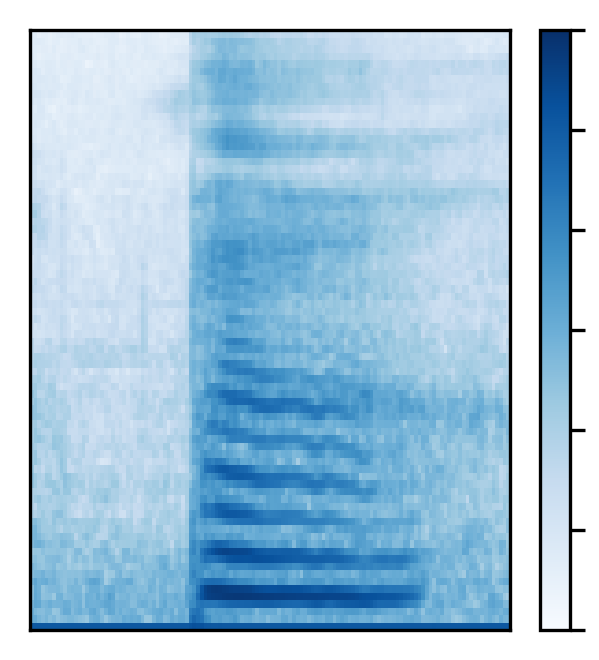

Fig. 5f


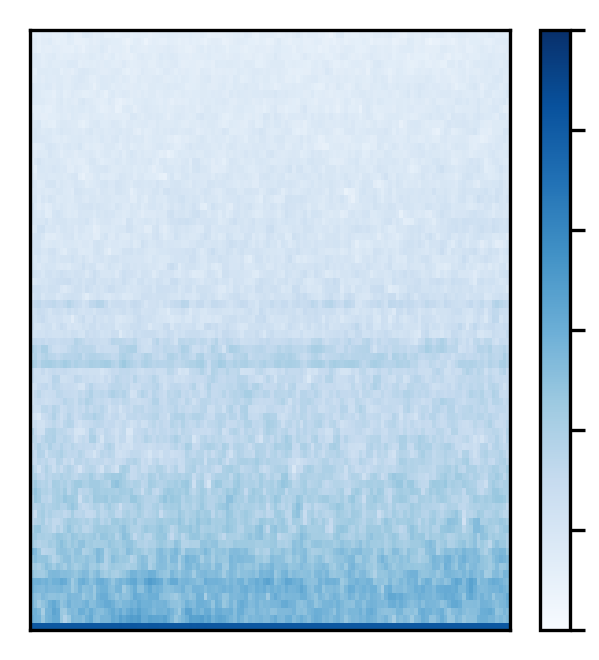

Fig. 5g


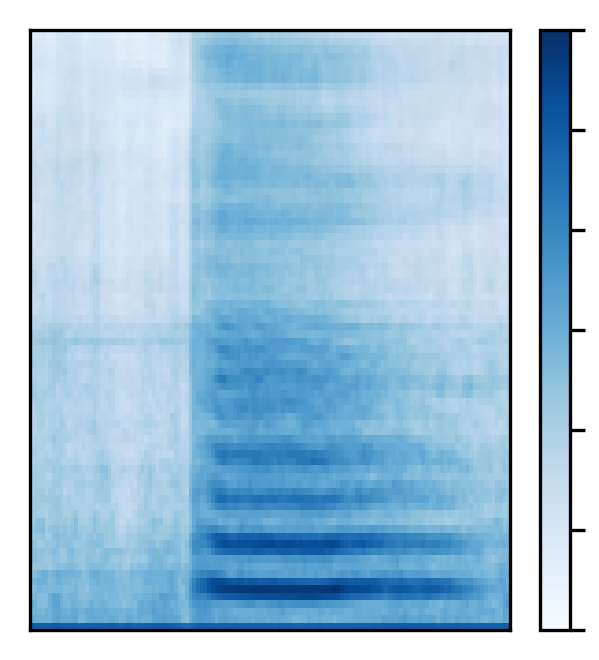

Fig. 5h


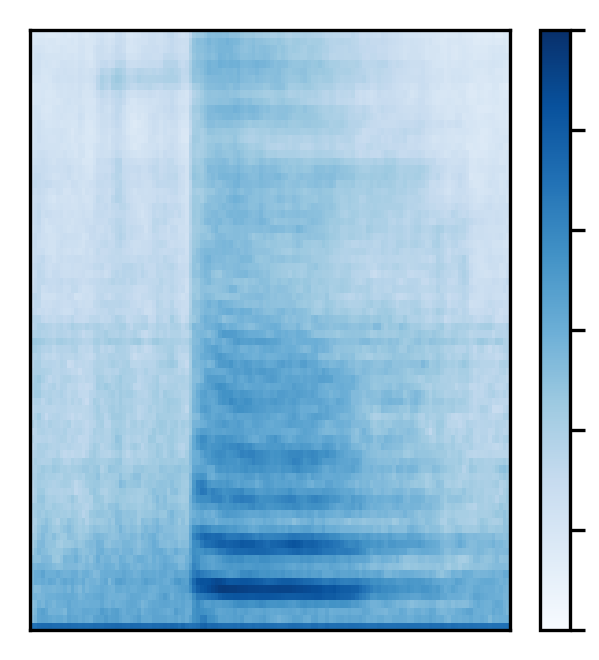

In [3]:
arrays_to_show = {
    'recorded_sa': 'Fig. 5e',
    'recorded_si': 'Fig. 5f',
    'synthesized_sa': 'Fig. 5g',
    'synthesized_si': 'Fig. 5h',
}
for csv_name, sheet_name in arrays_to_show.items():

    plot_mel_from_source(
        sheet_name=sheet_name,
        out_pdf=clean_data_path + f"/figures_R3/{sheet_name}.pdf",
    )